# Normalización en Redes Convolucionales

En una CNN, las activaciones pueden cambiar de escala entre capas. Si algunas activaciones tienen valores muy grandes, muy pequeños o distribuciones muy distintas, el entrenamiento puede volverse menos estable.

Las capas de normalización ayudan a controlar esas escalas. En esta notebook veremos cuatro métodos:

- Batch Normalization
- Instance Normalization
- Layer Normalization
- Group Normalization

La idea central es simple:

> Los métodos de normalización se diferencian principalmente por los ejes sobre los cuales calculan la media y la varianza.

Usaremos tensores con forma:

$$X \in \mathbb{R}^{N \times C \times H \times W}$$

Donde:

- $N$: tamaño del batch
- $C$: número de canales
- $H$: altura
- $W$: anchura

In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# Semillas para obtener resultados reproducibles.
torch.manual_seed(7)
np.random.seed(7)

## 1. Activaciones sintéticas

Primero creamos un tensor con cuatro canales. Cada canal tendrá una media y una escala distinta para que el efecto de la normalización sea visible.

In [2]:
batch_size = 8
num_channels = 8
height = 16
width = 16

channel_means = torch.tensor([0.0, 3.0, -2.0, 1.5, -1.0, 2.5, -3.0, 0.5]).view(1, num_channels, 1, 1)
channel_stds = torch.tensor([1.0, 0.5, 2.0, 1.5, 0.8, 2.5, 0.3, 1.2]).view(1, num_channels, 1, 1)
sample_shift = torch.linspace(-0.8, 0.8, batch_size).view(batch_size, 1, 1, 1)

activations = torch.randn(batch_size, num_channels, height, width)
activations = activations * channel_stds + channel_means + sample_shift

print(f"Forma del tensor de activaciones: {tuple(activations.shape)}")

Forma del tensor de activaciones: (8, 8, 16, 16)


## 2. Funciones simples para visualizar

Usaremos histogramas y tablas pequeñas. No necesitamos una arquitectura completa para entender qué hace cada normalización.

In [3]:
def plot_channel_histograms(tensor, title):
    values = tensor.detach().reshape(tensor.shape[0], tensor.shape[1], -1)

    plt.figure(figsize=(8, 4))
    for channel_index in range(tensor.shape[1]):
        channel_values = values[:, channel_index, :].reshape(-1).numpy()
        plt.hist(channel_values, bins=35, alpha=0.45, label=f"Canal {channel_index + 1}")

    plt.title(title)
    plt.xlabel("Valor de activación")
    plt.ylabel("Frecuencia")
    plt.legend()
    plt.tight_layout()
    plt.show()


def print_channel_statistics(tensor, title):
    means = tensor.mean(dim=(0, 2, 3))
    stds = tensor.std(dim=(0, 2, 3), unbiased=False)

    print(title)
    print("Canal | Media | Desviación estándar")
    print("------|-------|--------------------")
    for channel_index in range(tensor.shape[1]):
        print(f"{channel_index + 1:5d} | {means[channel_index]:6.3f} | {stds[channel_index]:18.3f}")

## 3. Distribuciones originales

Antes de normalizar, los canales no tienen la misma media ni la misma desviación estándar.

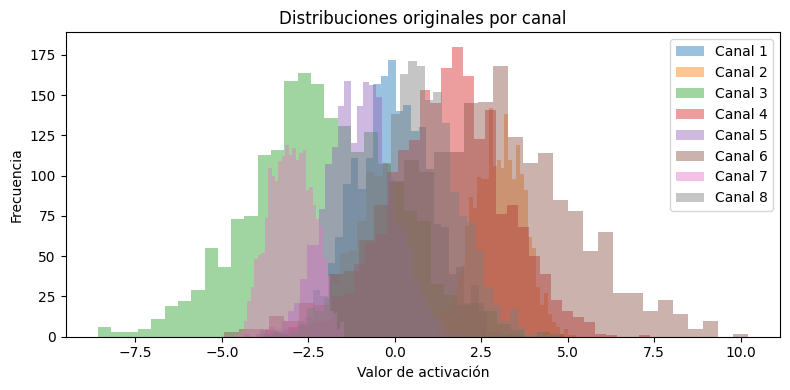

Estadísticas originales por canal
Canal | Media | Desviación estándar
------|-------|--------------------
    1 | -0.054 |              1.140
    2 |  3.018 |              0.707
    3 | -2.034 |              2.095
    4 |  1.557 |              1.603
    5 | -1.008 |              0.943
    6 |  2.496 |              2.495
    7 | -2.993 |              0.608
    8 |  0.532 |              1.263


In [4]:
plot_channel_histograms(activations, "Distribuciones originales por canal")
print_channel_statistics(activations, "Estadísticas originales por canal")

## 4. Batch Normalization

BatchNorm calcula una media y una varianza por canal.

Para cada canal usa los ejes: **N, H, W**.

Es decir: mezcla información del batch y de las posiciones espaciales, pero mantiene separados los canales.

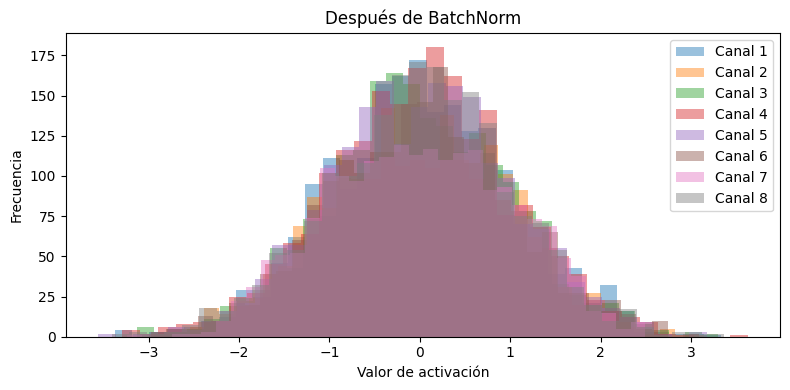

Estadísticas después de BatchNorm
Canal | Media | Desviación estándar
------|-------|--------------------
    1 |  0.000 |              1.000
    2 | -0.000 |              1.000
    3 |  0.000 |              1.000
    4 | -0.000 |              1.000
    5 | -0.000 |              1.000
    6 |  0.000 |              1.000
    7 | -0.000 |              1.000
    8 | -0.000 |              1.000


In [5]:
batch_norm = nn.BatchNorm2d(
    num_features=num_channels,
    affine=False,
    track_running_stats=False
)

batch_normalized = batch_norm(activations)

plot_channel_histograms(batch_normalized, "Después de BatchNorm")
print_channel_statistics(batch_normalized, "Estadísticas después de BatchNorm")

Después de BatchNorm, cada canal queda aproximadamente con media 0 y desviación estándar 1 cuando medimos sobre **N, H, W**.

## 5. Instance Normalization

InstanceNorm normaliza cada muestra y cada canal por separado.

Para cada combinación muestra-canal usa los ejes: **H, W**.

No usa información de otras imágenes del batch.

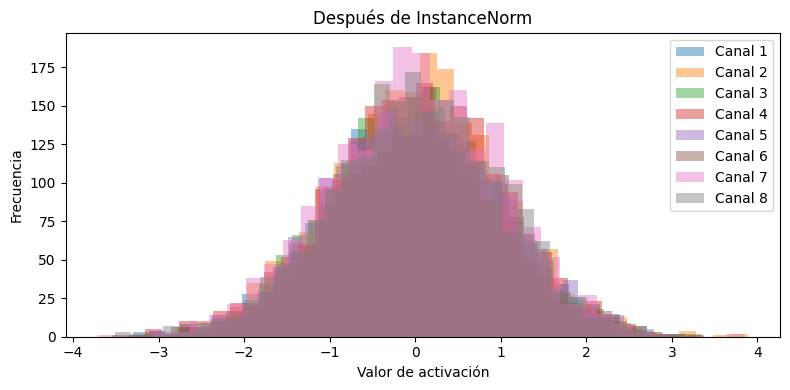

Resumen global después de InstanceNorm
Canal | Media | Desviación estándar
------|-------|--------------------
    1 | -0.000 |              1.000
    2 |  0.000 |              1.000
    3 |  0.000 |              1.000
    4 | -0.000 |              1.000
    5 | -0.000 |              1.000
    6 | -0.000 |              1.000
    7 |  0.000 |              1.000
    8 |  0.000 |              1.000


In [6]:
instance_norm = nn.InstanceNorm2d(
    num_features=num_channels,
    affine=False,
    track_running_stats=False
)

instance_normalized = instance_norm(activations)

plot_channel_histograms(instance_normalized, "Después de InstanceNorm")
print_channel_statistics(instance_normalized, "Resumen global después de InstanceNorm")

In [7]:
means = instance_normalized.mean(dim=(2, 3))
stds = instance_normalized.std(dim=(2, 3), unbiased=False)

print("InstanceNorm: primeras dos muestras")
print("Muestra | Canal | Media | Desviación estándar")
print("--------|-------|-------|--------------------")
for sample_index in range(2):
    for channel_index in range(num_channels):
        print(
            f"{sample_index + 1:7d} | {channel_index + 1:5d} | "
            f"{means[sample_index, channel_index]:6.3f} | "
            f"{stds[sample_index, channel_index]:18.3f}"
        )

InstanceNorm: primeras dos muestras
Muestra | Canal | Media | Desviación estándar
--------|-------|-------|--------------------
      1 |     1 | -0.000 |              1.000
      1 |     2 | -0.000 |              1.000
      1 |     3 |  0.000 |              1.000
      1 |     4 | -0.000 |              1.000
      1 |     5 | -0.000 |              1.000
      1 |     6 | -0.000 |              1.000
      1 |     7 |  0.000 |              1.000
      1 |     8 |  0.000 |              1.000
      2 |     1 | -0.000 |              1.000
      2 |     2 |  0.000 |              1.000
      2 |     3 |  0.000 |              1.000
      2 |     4 |  0.000 |              1.000
      2 |     5 | -0.000 |              1.000
      2 |     6 |  0.000 |              1.000
      2 |     7 | -0.000 |              1.000
      2 |     8 |  0.000 |              1.000


La diferencia con BatchNorm es importante: aqué cada imagen se normaliza de forma independiente por canal.

## 6. Layer Normalization

LayerNorm normaliza cada muestra completa.

Para cada muestra usa los ejes: **C, H, W**.

No depende del tamaño del batch.

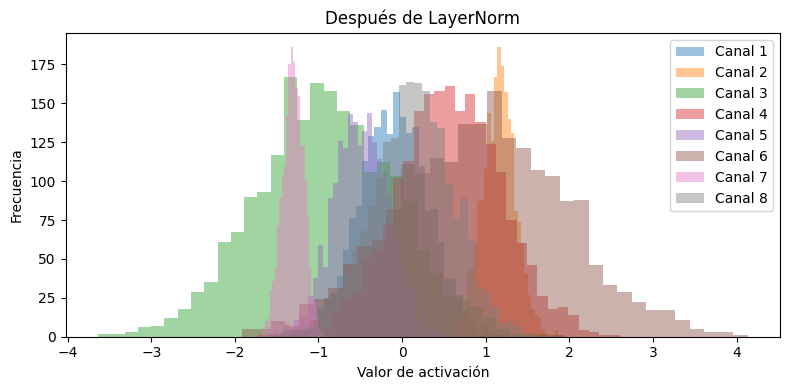

LayerNorm: estadísticas por muestra
Muestra | Media | Desviación estándar
--------|-------|--------------------
      1 | -0.000 |              1.000
      2 | -0.000 |              1.000
      3 |  0.000 |              1.000
      4 |  0.000 |              1.000
      5 | -0.000 |              1.000
      6 |  0.000 |              1.000
      7 | -0.000 |              1.000
      8 |  0.000 |              1.000


In [8]:
layer_norm = nn.LayerNorm(
    normalized_shape=[num_channels, height, width],
    elementwise_affine=False
)

layer_normalized = layer_norm(activations)

plot_channel_histograms(layer_normalized, "Después de LayerNorm")

means = layer_normalized.mean(dim=(1, 2, 3))
stds = layer_normalized.std(dim=(1, 2, 3), unbiased=False)

print("LayerNorm: estadísticas por muestra")
print("Muestra | Media | Desviación estándar")
print("--------|-------|--------------------")
for sample_index in range(batch_size):
    print(f"{sample_index + 1:7d} | {means[sample_index]:6.3f} | {stds[sample_index]:18.3f}")

LayerNorm no intenta que cada canal tenga media 0 por separado. Normaliza todo el bloque **C, H, W** de cada muestra.

## 7. Group Normalization

GroupNorm divide los canales en grupos.

En este ejemplo tenemos 4 canales y usaremos 2 grupos:

- Grupo 1: canales 1 y 2
- Grupo 2: canales 3 y 4

Para cada muestra y grupo usa los canales del grupo y los ejes espaciales **H, W**.

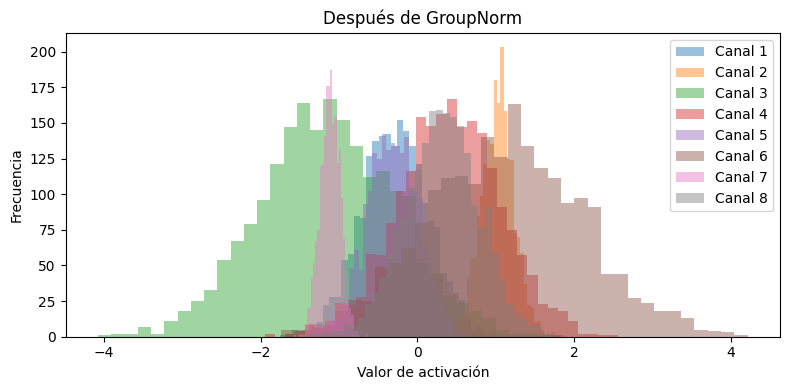

In [9]:
num_groups = 2

group_norm = nn.GroupNorm(
    num_groups=num_groups,
    num_channels=num_channels,
    affine=False
)

group_normalized = group_norm(activations)

plot_channel_histograms(group_normalized, "Después de GroupNorm")

In [10]:
channels_per_group = num_channels // num_groups
reshaped = group_normalized.reshape(batch_size, num_groups, channels_per_group, height, width)
means = reshaped.mean(dim=(2, 3, 4))
stds = reshaped.std(dim=(2, 3, 4), unbiased=False)

print("GroupNorm: primeras dos muestras")
print("Muestra | Grupo | Media | Desviación estándar")
print("--------|-------|-------|--------------------")
for sample_index in range(2):
    for group_index in range(num_groups):
        print(
            f"{sample_index + 1:7d} | {group_index + 1:5d} | "
            f"{means[sample_index, group_index]:6.3f} | "
            f"{stds[sample_index, group_index]:18.3f}"
        )

GroupNorm: primeras dos muestras
Muestra | Grupo | Media | Desviación estándar
--------|-------|-------|--------------------
      1 |     1 |  0.000 |              1.000
      1 |     2 |  0.000 |              1.000
      2 |     1 | -0.000 |              1.000
      2 |     2 |  0.000 |              1.000


GroupNorm queda entre InstanceNorm y LayerNorm: no normaliza cada canal totalmente separado, pero tampoco junta todos los canales de la muestra.

## 8. Comparación directa en una misma muestra y canal

Ahora comparamos un solo caso para evitar una gráfica saturada:

- muestra 1
- canal 1

La comparación no dice todo sobre cada método, pero ayuda a ver cómo cambian las distribuciones.

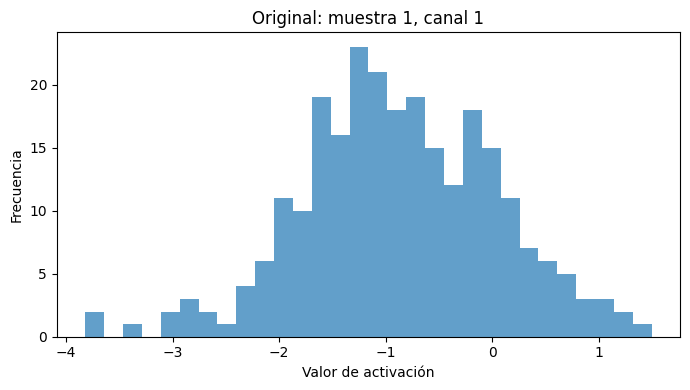

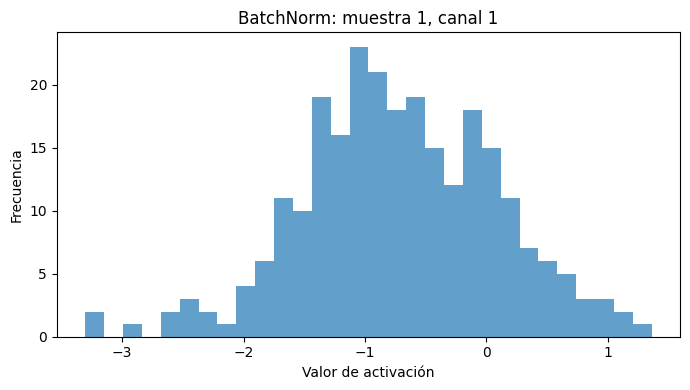

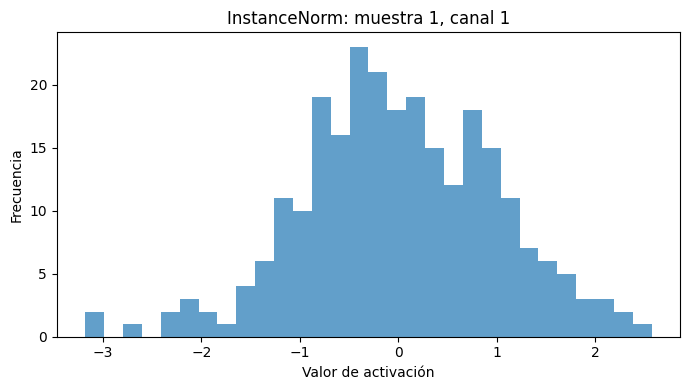

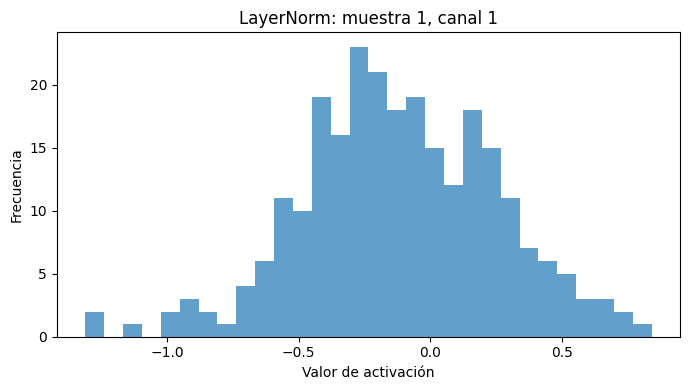

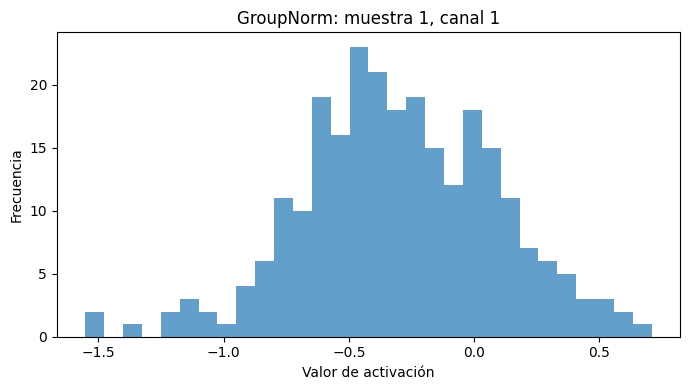

In [11]:
def plot_single_distribution(tensor, title, sample_index=0, channel_index=0):
    values = tensor[sample_index, channel_index].detach().reshape(-1).numpy()

    plt.figure(figsize=(7, 4))
    plt.hist(values, bins=30, alpha=0.7)
    plt.title(title)
    plt.xlabel("Valor de activación")
    plt.ylabel("Frecuencia")
    plt.tight_layout()
    plt.show()


plot_single_distribution(activations, "Original: muestra 1, canal 1")
plot_single_distribution(batch_normalized, "BatchNorm: muestra 1, canal 1")
plot_single_distribution(instance_normalized, "InstanceNorm: muestra 1, canal 1")
plot_single_distribution(layer_normalized, "LayerNorm: muestra 1, canal 1")
plot_single_distribution(group_normalized, "GroupNorm: muestra 1, canal 1")

## 9. Resumen de ejes

Esta tabla es el punto más importante de la notebook.

| Método | Estadísticas calculadas sobre | Depende del batch |
| --- | --- | --- |
| BatchNorm | (N, H, W), por canal | Sí |
| InstanceNorm | (H, W), por muestra y canal | No |
| LayerNorm | (C, H, W), por muestra | No |
| GroupNorm | grupos de canales y (H, W), por muestra | No |

## 10. Comparación final

| Método | Unidad normalizada | Usa estadísticas del batch | Caso ilustrativo |
| --- | --- | --- | --- |
| BatchNorm | Canal | Sí | CNN con batch suficiente |
| InstanceNorm | Muestra y canal | No | Estilo y generación |
| LayerNorm | Muestra completa | No | Normalización independiente del batch |
| GroupNorm | Grupos de canales | No | CNN con batch pequeño |

Conclusión:

> Las capas de normalización usan una transformación similar, pero comparten estadísticas entre diferentes elementos del tensor.

El beneficio principal es mantener escalas de activación más controladas y facilitar la optimización. El efecto final sobre la exactitud depende de la arquitectura, la tarea, el tamaño del batch y el proceso de entrenamiento.

La normalización estabiliza cada transformación. Las conexiones residuales, que se estudiarán después, crean una ruta directa para la información y los gradientes.